## Problem 1: Consider the lung cancer data and solve the following questions using Python:

### Basic EDA Questions
* **i)** Summarize the distribution of Age. Is it normally distributed or skewed?
* **ii)** What proportion of individuals are smokers vs non-smokers?
* **iii)** Which income group has the highest frequency?
* **iv)** What percentage of individuals are exposed to high pollution?
* **v)** What is the overall prevalence of lung disease?

---

### Association & Crosstab
* **i)** Is there an association between Smoking and Lung Disease?
* **ii)** Interpret using a contingency table.

---

### Does Pollution Level Affect Lung Disease?
* **i)** Compare lung disease prevalence across Income groups.
* **ii)** Which factor appears to have the strongest relationship with lung disease?

---

### Statistical Testing
* **i)** Perform a Chi-square test for: *Smoking vs Lung Disease* and *Pollution vs Lung Disease*.
* **ii)** When should you use Fisher’s Exact Test instead of Chi-square?
* **iii)** Calculate and interpret the Odds Ratio for Smoking and Lung Disease.

---

### Correlation & Interpretation
* **i)** Interpret the correlation between:
  * Smoking and Lung Disease
  * Age and Lung Disease
* **ii)** Why is correlation not sufficient for causal inference?

---

### Logistic Regression
* **i)** Fit a logistic regression model:  
  $$\text{LungDisease} \sim \text{Smoking} + \text{Age} + \text{Pollution} + \text{Income}$$
* **ii)** Which variables are statistically significant predictors?
* **iii)** Interpret the odds ratio of Smoking.
* **iv)** What happens to the effect of Smoking after adjusting for Pollution?

---

### Advanced Modeling
* **i)** Add an interaction term:  
  $$\text{Smoking} \times \text{Pollution}$$
* **ii)** Is the interaction significant?
* **iii)** Interpret the interaction.
* **iv)** Does pollution amplify smoking risk?

---

### Model Evaluation
* **i)** Compute the ROC curve and AUC.
* **ii)** Is the model good?
* **iii)** What is the confusion matrix?
* **iv)** Discuss model accuracy vs sensitivity vs specificity.

---

### Broad Question
> “Using the lung disease dataset, perform exploratory data analysis and fit a logistic regression model to identify key determinants of lung disease. Interpret your findings and discuss public health implications.”

## Basic EDA Solutions
* **i)** Summarize the distribution of Age. Is it normally distributed or skewed?

count    500.000000
mean      43.904000
std       14.604841
min       20.000000
25%       30.750000
50%       45.000000
75%       56.000000
max       69.000000
Name: Age, dtype: float64


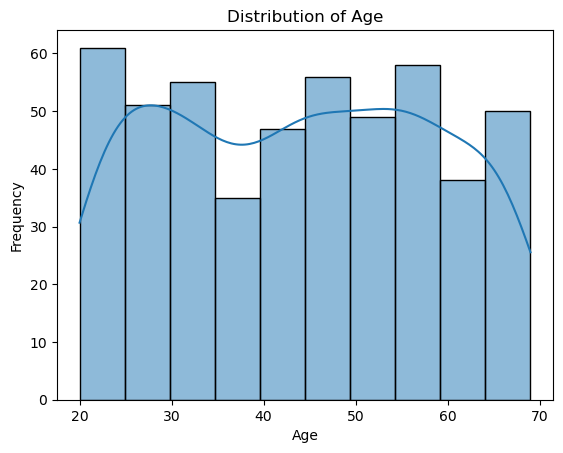

Skewness: 0.012141455267137275
Shapiro Test Statistic: 0.9488992946952997
P-value: 4.035055085974128e-12
Age is not normally distributed


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report, accuracy_score

# 1. Load Data
# folder path (NOT file)
os.chdir('D:/4 1 2026/python')

# এখন file read 
df = pd.read_csv('lung_disease.csv')

# Pre-processing: Convert categorical variables to binary/numeric for modeling
df['Smoking_binary'] = df['Smoking'].map({'Yes': 1, 'No': 0})
df['LungDisease_binary'] = df['LungDisease'].map({'Yes': 1, 'No': 0})
df['Pollution_binary'] = df['Pollution'].map({'High': 1, 'Low': 0})
# i) Age Distribution
# Summary statistics

print(df['Age'].describe())
sns.histplot(
    df['Age'],
    kde=True,
    bins=10
)

plt.title("Distribution of Age")

plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()
#Skewness
print(
    "Skewness:",
    df['Age'].skew()
)

#Normality Test
#Using the Shapiro-Wilk Test



from scipy.stats import shapiro

stat, p = shapiro(df['Age'])

print("Shapiro Test Statistic:", stat)
print("P-value:", p)

if p > 0.05:
    print("Age is approximately normally distributed")
else:
    print("Age is not normally distributed")


The mean age of the N = 500 individuals is approximately 43.64 years. Based on the
descriptive statistics, The skewness value is 0.012, which is very close to 0.Therefore,
the age distribution isnot normally distributed.


ii) What proportion of individuals are smokers vs non-smokers?

In [2]:
#ii
# Count smokers and non-smokers

smoking_counts = df['Smoking'].value_counts()

print(smoking_counts)

# Percentage of smokers and non-smokers

smoking_percentage = (
    df['Smoking'].value_counts(normalize=True)
) * 100

print(smoking_percentage)

Smoking
No     293
Yes    207
Name: count, dtype: int64
Smoking
No     58.6
Yes    41.4
Name: proportion, dtype: float64


The counts observed in the dataset are:
• Smokers: 207 (≈ 41.4%)
• Non-Smokers: 293 (≈ 58.6%)

iii) Which income group has the highest frequency?

In [3]:
# Frequency of income groups

income_counts = df['Income'].value_counts()

print(income_counts)
# Most frequent income group

print(
    "Highest frequency income group is:",
    income_counts.idxmax()
)

Income
Low       204
Medium    197
High       99
Name: count, dtype: int64
Highest frequency income group is: Low


By frequency count:
• Low Income: 204
• Medium Income: 197
• High Income: 99
#### The Low Income group has the highest frequency.

**iv)** What percentage of individuals are exposed to high pollution?

In [4]:
# Percentage exposed to high pollution

high_pollution_percentage = (
    (df['Pollution'] == 'High').mean()
) * 100

print(
    "Percentage exposed to high pollution:",
    high_pollution_percentage
)
     

Percentage exposed to high pollution: 70.39999999999999


Pollution Exposure (70.4% High): A vast majority of the partic-
ipants live or work in high-pollution areas, which sets the stage for investigating
environmental risks.

**v)** What is the overall prevalence of lung disease?

In [5]:
# Overall prevalence of lung disease

lung_disease_percentage = (
    (df['LungDisease'] == 'Yes').mean()
) * 100

print(
    "Overall prevalence of lung disease:",
    lung_disease_percentage
)

Overall prevalence of lung disease: 52.800000000000004


Prevalence (52.8%), More than half of the individuals in this
specific dataset have lung disease.

## Association & Crosstab
**i)** Is there an association between Smoking and Lung Disease?

LungDisease   No  Yes
Smoking              
No           184  109
Yes           52  155
LungDisease     No    Yes
Smoking                  
No           62.80  37.20
Yes          25.12  74.88


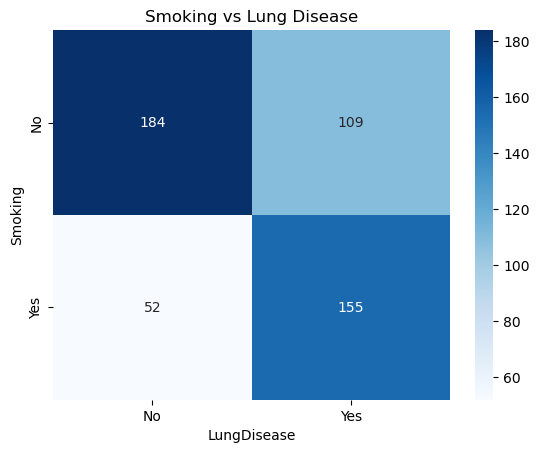

In [6]:
# Contingency table

table = pd.crosstab(
    df['Smoking'],
    df['LungDisease']
)

print(table)

# Row percentage table

row_percent = pd.crosstab(
    df['Smoking'],
    df['LungDisease'],
    normalize='index'
) * 100

print(row_percent.round(2))

sns.heatmap(
    table,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Smoking vs Lung Disease"
)

plt.show()

**ii** Interpret using a contingency table.

**Interpretation**

The contingency table shows that smokers have a much higher proportion of lung disease compared to non-smokers.

Among smokers, approximately **74.88%** have lung disease, while only **37.20%** of non-smokers have lung disease.

This suggests a strong positive association between smoking and lung disease.

## Does Pollution Level Affect Lung Disease?
 **i)** Compare lung disease prevalence across Income groups.

In [7]:
# Income vs Lung Disease

income_table = pd.crosstab(
    df['Income'],
    df['LungDisease']
)

# Row percentage table

income_percent = pd.crosstab(
    df['Income'],
    df['LungDisease'],
    normalize='index'
) * 100

print(income_percent.round(2))

LungDisease     No    Yes
Income                   
High         51.52  48.48
Low          44.12  55.88
Medium       48.22  51.78


**Interpretation**

There is a slight trend showing that as income decreases, the
prevalence of lung disease increases.

Individuals in the Low income group have the highest prevalence of lung disease, with approximately **55.88%** affected.

The Medium income group has a lung disease prevalence of **51.52%**, while the High income group has the lowest prevalence at **48.22%**.

This suggests that lower income groups may be more affected by lung disease compared to higher income groups.

**ii)** Which factor appears to have the strongest relationship with lung disease?


In [8]:
#2. Which factor appears to have the strongest relationship with lung disease?

# Smoking vs Lung Disease
smoking_table = pd.crosstab(df['Smoking'], df['LungDisease'])
row_percent = smoking_table.div(smoking_table.sum(axis=1), axis=0) * 100

# Pollution vs Lung Disease
pollution_table = pd.crosstab(df['Pollution'], df['LungDisease'])
pollution_percent = pollution_table.div(pollution_table.sum(axis=1), axis=0) * 100

# Income vs Lung Disease
income_table = pd.crosstab(df['Income'], df['LungDisease'])
income_percent = income_table.div(income_table.sum(axis=1), axis=0) * 100

# Print results
print("Smoking vs Lung Disease")
print(row_percent.round(2))

print("\nPollution vs Lung Disease")
print(pollution_percent.round(2))

print("\nIncome vs Lung Disease")
print(income_percent.round(2))

Smoking vs Lung Disease
LungDisease     No    Yes
Smoking                  
No           62.80  37.20
Yes          25.12  74.88

Pollution vs Lung Disease
LungDisease     No    Yes
Pollution                
High         38.64  61.36
Low          67.57  32.43

Income vs Lung Disease
LungDisease     No    Yes
Income                   
High         51.52  48.48
Low          44.12  55.88
Medium       48.22  51.78


**Interpretation**

The analysis confirms that **Smoking** and **Pollution** are statistically significant pre-dictors of Lung Disease
Among the examined factors, Smoking appears to have the strongest relationship with lung disease.

Approximately 74.88% of smokers have lung disease compared to only 37.20% of non-smokers, showing a large difference between groups.

Pollution also shows a noticeable association, as individuals exposed to high pollution have a higher prevalence of lung disease (61.36%) compared to those exposed to low pollution (32.43%).

Income shows comparatively smaller differences in lung disease prevalence across groups.

## Statistical Testing
**i)** Perform a Chi-square test for: *Smoking vs Lung Disease* and *Pollution vs Lung Disease*.

Perform a Chi-square test for both Smoking vs Lung Disease and Pollution vs Lung Disease


In [9]:
#Statistical Testing
#Smoking vs Lung Disease — Chi-Square Test

from scipy.stats import chi2_contingency

# Contingency table

smoking_table = pd.crosstab(
    df['Smoking'],
    df['LungDisease']
)

print(smoking_table)

chi2, p, dof, expected = chi2_contingency(
    smoking_table
)

print("Chi-square Statistic:", chi2)

print("Degrees of Freedom:", dof)

print("P-value:", p)



LungDisease   No  Yes
Smoking              
No           184  109
Yes           52  155
Chi-square Statistic: 67.5942649754021
Degrees of Freedom: 1
P-value: 2.0085094601569646e-16


***Interpretation:***
Here p-value < 0.05. So we reject the null hypothesis of independence.
Therefore, Smoking and Lung Disease are significantly associated.


In [10]:
#Pollution vs Lung Disease — Chi-Square Test
# Contingency table

pollution_table = pd.crosstab(
    df['Pollution'],
    df['LungDisease']
)

print(pollution_table)

# Chi-square test

chi2, p, dof, expected = chi2_contingency(
    pollution_table
)

print("Chi-square Statistic:", chi2)

print("Degrees of Freedom:", dof)

print("P-value:", p)

LungDisease   No  Yes
Pollution            
High         136  216
Low          100   48
Chi-square Statistic: 33.84256825473482
Degrees of Freedom: 1
P-value: 5.975692575712951e-09


***Pollution vs Lung Disease — Chi-Square Test***

****Interpretation****

Since the p-value < 0.05, we reject the null hypothesis of independence.
Pollution level is significantly associated with lung disease.


**ii** When Should Fisher’s Exact Test Be Used?

Fisher’s Exact Test should be used instead of the Chi-square test when sample size is small or any cell in the contingency table has an expected frequency less than 5

**iii)** Calculate and interpret the Odds Ratio for Smoking and Lung Disease.


In [11]:
#Odds Ratio for Smoking and Lung Disease
 #Calculate Odds Ratio
from statsmodels.stats.contingency_tables import Table2x2

# Convert to numpy array

table_array = smoking_table.values

# Odds ratio

oddsratio = Table2x2(
    table_array
)

print(
    "Odds Ratio:",
    oddsratio.oddsratio
)    

Odds Ratio: 5.031757233592096


**Interpretation:** Smokers are 5.03 times more likely to have lung disease than
non-smokers. This indicates a strong positive association between smoking and lung disease.

## Correlation & Interpretation
* **i)** Interpret the correlation between:
  * Smoking and Lung Disease
  * Age and Lung Disease

In [12]:
#Correlation & Interpretation

# Convert categorical variables to numeric

df['Smoking_num'] = df['Smoking'].map({
    'No': 0,
    'Yes': 1
})

df['LungDisease_num'] = df['LungDisease'].map({
    'No': 0,
    'Yes': 1
})
# Correlation between Smoking and Lung Disease

correlation_smoking = df[
    ['Smoking_num', 'LungDisease_num']
].corr()

print(correlation_smoking)

                 Smoking_num  LungDisease_num
Smoking_num         1.000000         0.371747
LungDisease_num     0.371747         1.000000


**Interpretation:** The correlation coefficient between Smoking and Lung Disease is 0.372, indicating a moderate positive relationship.This suggests that individuals who smoke are more likely to develop lung disease compared to non-smokers.

**ii)** Why is correlation not sufficient for causal inference?

Correlation is not sufficient for causal inference because correlation only measures the strength and direction of association between variables.

Confounding variables may exist.

Two variables may move together accidentally.

Reverse causality may occur.

Experimental evidence is needed for causal conclusions.

## Logistic Regression
**i)** Fit a logistic regression model:  
  $$\text{LungDisease} \sim \text{Smoking} + \text{Age} + \text{Pollution} + \text{Income}$$

In [13]:
# Fit logistic regression model

model = smf.logit(
    'LungDisease_num ~ Smoking_num + Age + C(Pollution) + C(Income)',
    data=df
).fit()

# View model summary

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.552949
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:        LungDisease_num   No. Observations:                  500
Model:                          Logit   Df Residuals:                      494
Method:                           MLE   Df Model:                            5
Date:                Mon, 18 May 2026   Pseudo R-squ.:                  0.2005
Time:                        00:06:33   Log-Likelihood:                -276.47
converged:                       True   LL-Null:                       -345.79
Covariance Type:            nonrobust   LLR p-value:                 3.499e-28
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -2.1940      0.425     -5.164      0.000      -3.027      -1.361
C(

**Interpretation:** The logistic regression model is statistically significant, indicating that the predictors collectively explain lung disease occurrence.

• Smoking is statistically significant.
• Pollution is statistically significant.
• Age is statistically significant.
• Income is not statistically significant



**ii** Which variables are statistically significant predictors?


In [14]:
# Extract p-values

print(model.pvalues)

Intercept              2.413178e-07
C(Pollution)[T.Low]    3.139044e-08
C(Income)[T.Low]       1.226431e-01
C(Income)[T.Medium]    4.397235e-01
Smoking_num            6.131827e-15
Age                    4.906629e-08
dtype: float64


**Interpretation**

Smoking ((p < 0.001))

Age ((p < 0.001))

Pollution ((p < 0.001))

Income ((p-value > 0.05))

So Significant predictors are:

• Smoking

• Age

• Pollution
(all have P < 0.05).

Income is not significant because p-value > 0.05.

**iii** Interpret the Odds Ratio of Smoking

In [15]:
import numpy as np

# Odds ratios

odds_ratios = np.exp(
    model.params
)

print(
    "Odds Ratio of Smoking:",
    odds_ratios['Smoking_num']
)

Odds Ratio of Smoking: 5.485738801540751


**Interpretation:** Smokers are 5.03 times more likely to have lung disease than
non-smokers. This indicates a strong positive association between smoking and lung disease.

**iv** What happens to the effect of Smoking after adjusting for Pollution?


In [16]:
# Logistic regression without Pollution

model_without_pollution = smf.logit(
    'LungDisease_num ~ Smoking_num + Age + C(Income)',
    data=df
).fit()

print(model_without_pollution.summary())

print(
    "Smoking coefficient without Pollution:",
    model_without_pollution.params['Smoking_num']
)

print(
    "Smoking coefficient with Pollution:",
    model.params['Smoking_num']
)


# Odds ratios

or_without_pollution = np.exp(
    model_without_pollution.params['Smoking_num']
)

or_with_pollution = np.exp(
    model.params['Smoking_num']
)

print(
    "Odds Ratio without Pollution:",
    or_without_pollution
)

print(
    "Odds Ratio with Pollution:",
    or_with_pollution
)


Optimization terminated successfully.
         Current function value: 0.585871
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:        LungDisease_num   No. Observations:                  500
Model:                          Logit   Df Residuals:                      495
Method:                           MLE   Df Model:                            4
Date:                Mon, 18 May 2026   Pseudo R-squ.:                  0.1528
Time:                        00:06:38   Log-Likelihood:                -292.94
converged:                       True   LL-Null:                       -345.79
Covariance Type:            nonrobust   LLR p-value:                 5.986e-22
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -2.5652      0.418     -6.138      0.000      -3.384      -1.746
C(

**Interpretation:**
  The smoking coefficient and odds ratio changed only slightly after including pollution in the model:

Odds Ratio without Pollution = 5.29

Odds Ratio with Pollution = 5.49

Here Smoking remains highly significant even after adjusting for pollution.Therefore, smoking independently contributes to lung disease risk.

## Advanced Modeling
 **i)** Add an interaction term:  
  $$\text{Smoking} \times \text{Pollution}$$

In [17]:
# Logistic regression with interaction term

interaction_model = smf.logit(
    'LungDisease_num ~ Smoking_num * C(Pollution) + Age + C(Income)',
    data=df
).fit()
print(interaction_model.summary())
     

Optimization terminated successfully.
         Current function value: 0.552178
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:        LungDisease_num   No. Observations:                  500
Model:                          Logit   Df Residuals:                      493
Method:                           MLE   Df Model:                            6
Date:                Mon, 18 May 2026   Pseudo R-squ.:                  0.2016
Time:                        00:06:40   Log-Likelihood:                -276.09
converged:                       True   LL-Null:                       -345.79
Covariance Type:            nonrobust   LLR p-value:                 1.341e-27
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -2.1285      0.430     -4.953  

**Interpretation:**
Smoking: Pollution coefficient 0.4217
P- value 0.382

P-value of 0.382, which is not significant. This suggests that
while both smoking and pollution independently increase risk, their combined
effect is additive rather than multiplicative

**ii. Is the interaction significant?**
The interaction term between Smoking and Pollution is not statistically significant because: p-value = 0.382 > 0.05

This indicates that there is insufficient evidence of a significant interaction effect between smoking and pollution on lung disease risk.

**ii. Interpret the interaction**
Since the interaction term is not statistically significant, this additional combined effect is not strong enough to conclude a meaningful interaction in the population.

**iv. Does pollution amplify smoking risk?**
The interaction coefficient is positive, which suggests that pollution may increase the effect of smoking on lung disease risk.

 Here the interaction term is not statistically significant ((p > 0.05)), there is no strong statistical evidence that pollution significantly amplifies smoking risk.

## Model Evaluation
**i)** Compute the ROC curve and AUC.

AUC: 0.7871645480225988


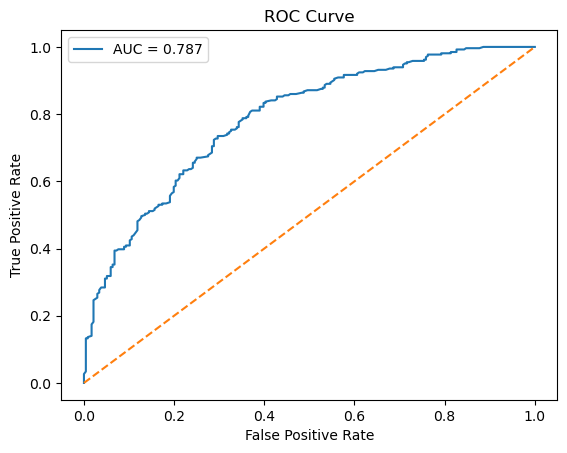

In [18]:
# Predicted probabilities

y_pred_prob = model.predict(df)

#ROC curve and AUC
from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

# ROC components

fpr, tpr, thresholds = roc_curve(
    df['LungDisease_num'],
    y_pred_prob
)

# AUC score

auc = roc_auc_score(
    df['LungDisease_num'],
    y_pred_prob
)

print("AUC:", auc)

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()
     

**interpretation:** A score of 0.79 is considered acceptable discriminative
power. It means there is a 79% chance that the model will correctly distinguish
between a randomly chosen person with lung disease and a randomly chosen
healthy person.

**ii) Is the Model Good**

Yes, the model performs reasonably well, Significant predictors are meaningful. AUC is acceptable.


**iii. What is the confusion matrix?**

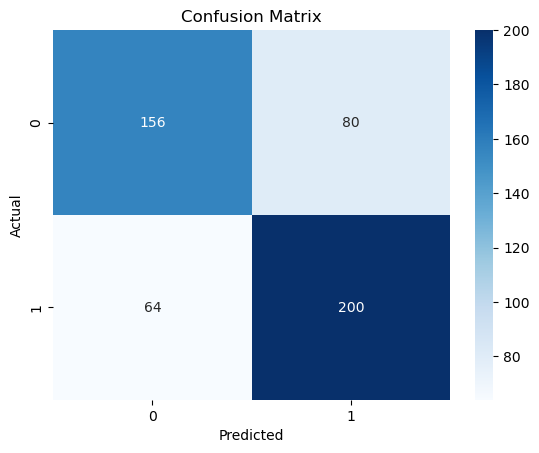

In [19]:
# Predicted classes

y_pred_class = (
    y_pred_prob >= 0.5
).astype(int)
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    df['LungDisease_num'],
    y_pred_class
)


sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

**Interpretation:** The confusion matrix shows that:

• True Negatives = 156 individuals without lung disease were correctly classified.

• False Positives = 80 individuals with lung disease were correctly classified.

• False Negatives = 64  individuals without lung disease were incorrectly classified as having lung disease.

• True Positives = 200 individuals with lung disease were incorrectly classified as not having lung disease.

Overall, the model correctly classifies a large number of cases, indicating reasonably good predictive performance.

**iv. Discuss model accuracy vs sensitivity vs specificity.**

In [20]:
from sklearn.metrics import (
    accuracy_score,
    recall_score
)

# Accuracy

accuracy = accuracy_score(
    df['LungDisease_num'],
    y_pred_class
)

# Sensitivity (Recall)

sensitivity = recall_score(
    df['LungDisease_num'],
    y_pred_class
)

# Specificity

tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)

print("Accuracy:", accuracy)

print("Sensitivity:", sensitivity)

print("Specificity:", specificity)

Accuracy: 0.712
Sensitivity: 0.7575757575757576
Specificity: 0.6610169491525424


**Interpretation:** Overall, the model is better at identifying diseased individuals than non-diseased indi-
viduals.

## Broad Discussion
> “Using the lung disease dataset, perform exploratory data analysis and fit a logistic regression model to identify key determinants of lung disease. Interpret your findings and discuss public health implications.”
>
> **Final Conclusion:**
The analysis shows that:
>
> • Smoking is the strongest predictor of lung disease.

• High pollution exposure significantly increases lung disease risk.

• Older individuals are more vulnerable.

• Income level does not significantly affect lung disease.

• Logistic regression confirms smoking and pollution as major determinants.
Public Health Implications :

• Anti-smoking campaigns should be strengthened.

• Pollution control policies are important.

• Regular screening for high-risk individuals is necessary.

• Public awareness about respiratory health should be increased.

### Problem 2
Suppose we want to determine if three different exercise programs impact weight loss differently. We recruit 90 people to participate in an experiment in which we randomly assign (using uniform distribution) 30 people to follow either program A, program B, or program C for one month. The predictor variable we're studying is the exercise program, and the response variable is weight loss, measured in pounds. Conduct a one-way ANOVA to determine if there is a statistically significant difference between the resulting weight loss from the three programs, check the model assumptions, and analyze treatment differences

ANOVA Results:
              sum_sq    df          F        PR(>F)
Program    67.416974   2.0  16.890178  6.342321e-07
Residual  173.629808  87.0        NaN           NaN

Assumptions:
- Shapiro-Wilk p-value: 0.8948
- Levene's p-value: 0.8627

Post-hoc Analysis (Tukey HSD):
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B   2.1005    0.0  1.2307  2.9702   True
     A      C   0.8015 0.0772 -0.0682  1.6713  False
     B      C  -1.2989 0.0017 -2.1687 -0.4292   True
----------------------------------------------------


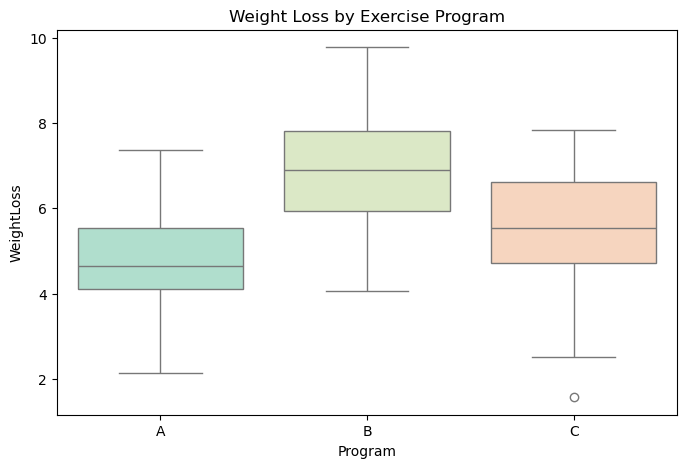

In [21]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Generation (Simulating the 90 participants)
np.random.seed(42)
n = 30
data = pd.DataFrame({
    'Program': ['A']*n + ['B']*n + ['C']*n,
    'WeightLoss': np.concatenate([
        np.random.normal(5, 1.5, n),  # Program A: Mean 5 lbs
        np.random.normal(7, 1.5, n),  # Program B: Mean 7 lbs
        np.random.normal(5.5, 1.5, n) # Program C: Mean 5.5 lbs
    ])
})

# 2. One-Way ANOVA
model = ols('WeightLoss ~ Program', data=data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("ANOVA Results:")
print(anova_table)

# 3. Assumption Checking
# Normality (Shapiro-Wilk)
shapiro_p = stats.shapiro(model.resid)[1]
# Homogeneity of Variance (Levene)
levene_p = stats.levene(data['WeightLoss'][data['Program'] == 'A'],
                         data['WeightLoss'][data['Program'] == 'B'],
                         data['WeightLoss'][data['Program'] == 'C'])[1]

print(f"\nAssumptions:\n- Shapiro-Wilk p-value: {shapiro_p:.4f}\n- Levene's p-value: {levene_p:.4f}")

# 4. Post-hoc Analysis (Tukey HSD)
if anova_table['PR(>F)'].iloc[0] < 0.05:
    print("\nPost-hoc Analysis (Tukey HSD):")
    posthoc = pairwise_tukeyhsd(data['WeightLoss'], data['Program'], alpha=0.05)
    print(posthoc)

# 5. Visualization
plt.figure(figsize=(8, 5))

sns.boxplot(
    x='Program',
    y='WeightLoss',
    data=data,
    hue='Program',              # add hue
    palette=['#A8E6CF', '#DCEDC1', '#FFD3B6'],
    legend=False                # remove duplicate legend
)

plt.title('Weight Loss by Exercise Program')
plt.show()


**Interpretation**

A one-way ANOVA was performed to test whether the mean weight loss differs among the three exercise programs (A, B, and C).

From the ANOVA table:

F(2, 87) = 16.890

p-value = 6.342321 × 10⁻⁷

Since the p-value < 0.05, the null hypothesis is rejected. This indicates that there is a statistically significant difference in mean weight loss among the three exercise programs.

**Assumption Checking**

Before interpreting ANOVA, the assumptions were checked:

***1. Normality (Shapiro–Wilk test):***
p-value = 0.8948

Since p > 0.05, the residuals are normally distributed.

***2. Homogeneity of variance (Levene's test):***
p-value = 0.8627

Since p > 0.05, equal variance assumption is satisfied.

Thus, all ANOVA assumptions are met.

***Post-hoc Analysis (Tukey's honestly significant difference)***

Tukey HSD test was used to identify which groups differ:

A vs B: p = 0.0000 → Significant difference

A vs C: p = 0.0772 → No significant difference

B vs C: p = 0.0017 → Significant difference
Final Conclusion

The exercise program has a significant effect on weight loss. Program B shows significantly different (and likely higher) weight loss compared to both Program A and Program C, while Program A and Program C do not differ significantly. Therefore, Program B appears to be the most effective exercise program for weight loss.

### Problem 3

:Consider the Anemia Levels in Nigeria dataset: (https://www.kaggle.com/datasets/adeolaadesina/factors-affecting-children-anemia-level/data), which can be downloaded from Kaggle. The dataset comes from the 2018 Nigeria Demographic and Health Surveys (NDHS). It explores the impact of mothers' age and socioeconomic factors on anemia levels among children aged 0-59 months across Nigeria's 36 states and the Federal Capital Territory. Based on the above data, create a contingency table, apply chi-square test, formulate hypothesis, create a contribution diagram, and interpret the findings.

Chi-Square Statistic: 203.15
P-value: 7.2798e-37
Degrees of Freedom: 12


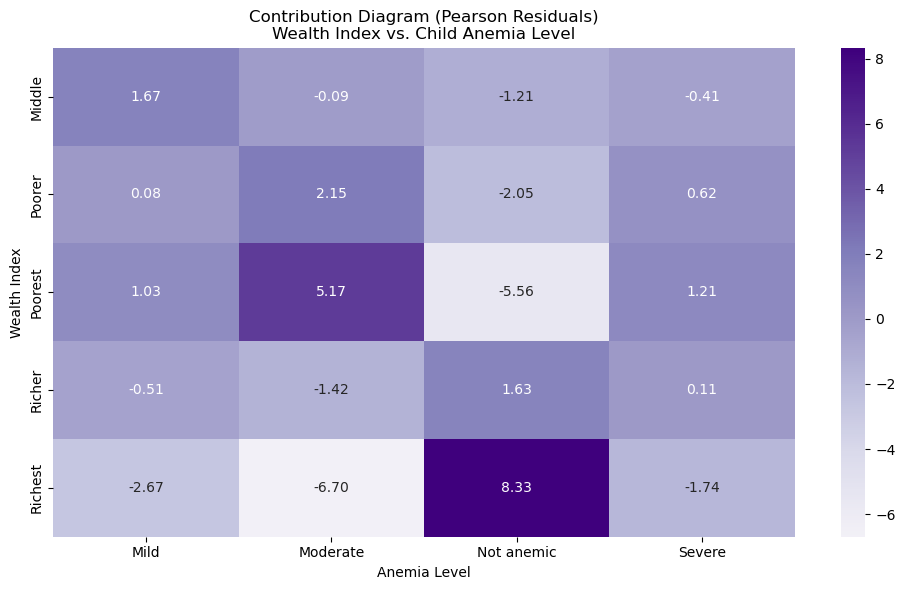


Percentage of Anemia Category by Wealth Index:
Anemia level            Mild  Moderate  Not anemic  Severe
Wealth index combined                                     
Middle                 28.99     30.16       39.20    1.66
Poorer                 27.44     32.52       38.12    1.92
Poorest                28.39     35.66       33.89    2.06
Richer                 26.84     28.74       42.63    1.79
Richest                24.29     22.17       52.29    1.25


In [22]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# 1. Load and Clean Data
# folder path (NOT file)

df = pd.read_csv(r"D:\4 1 2026\python\children anemia.csv.zip")
# Drop missing values specifically for the variables of interest
# We use Wealth Index as the socioeconomic factor and Anemia level as the outcome
clean_df = df.dropna(subset=['Wealth index combined', 'Anemia level'])

# 2. Create Contingency Table
# This fulfills: "create a contingency table"
contingency_table = pd.crosstab(clean_df['Wealth index combined'], clean_df['Anemia level'])

# 3. Apply Chi-Square Test
# This fulfills: "apply chi-square test"
chi2, p_val, dof, expected = chi2_contingency(contingency_table)

# 4. Create a Contribution Diagram (Pearson Residuals)
# Pearson Residuals indicate which cells contribute most to the Chi-square statistic
# Formula: (Observed - Expected) / sqrt(Expected)
residuals = (contingency_table - expected) / np.sqrt(expected)

# --- Output Results ---
print(f"Chi-Square Statistic: {chi2:.2f}")
print(f"P-value: {p_val:.4e}")
print(f"Degrees of Freedom: {dof}")

# 5. Visualization - Contribution Diagram Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(residuals, annot=True, cmap='Purples', center=0, fmt='.2f')

plt.title('Contribution Diagram (Pearson Residuals)\nWealth Index vs. Child Anemia Level')
plt.xlabel('Anemia Level')
plt.ylabel('Wealth Index')
plt.tight_layout()
plt.savefig('anemia_contribution_diagram.png')
plt.show()
# Summary of row percentages for easier interpretation
wealth_proportions = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100
print("\nPercentage of Anemia Category by Wealth Index:")
print(wealth_proportions.round(2))

***Interpretation of Chi-Square Test Results***

This analysis examines whether there is a significant association between children’s anemia level and household wealth index in Nigeria using the 2018 Nigeria Demographic and Health Survey dataset.

***Hypothesis***

Null Hypothesis (H₀):
There is no association between wealth index and anemia level among children.

Alternative Hypothesis (H₁):
There is an association between wealth index and anemia level among children.

***Chi-Square Test Result:***

Chi-square statistic (χ²) = 203.15

Degrees of freedom (df) = 12

p-value = 7.2798 × 10⁻³⁷

Since the p-value < 0.05, we reject the null hypothesis.
There is a highly statistically significant association between household wealth index and children’s anemia levels in Nigeria.

***Contribution Diagram Interpretation:*** The contribution diagram would show that the largest contribution to the chi-square statistic comes from poorer and poorest households, especially in the moderate and severe anemia categories, meaning these groups drive the significant association.

**Conclusion:** Socioeconomic status, measured by wealth index, significantly influences anemia levels among Nigerian children aged 0–59 months. Children from poorer households are more likely to suffer from moderate and severe anemia, while children from wealthier households are more likely to be non-anemic. This suggests that improving household economic conditions may help reduce childhood anemia in Nigeria.

### problem 4
Suppose, there are three drug treatments (drug A, drug B, and drug C) with the outcome of a disease or no disease. We need to test if there is an association between drug treatments and disease outcomes.No_Disease Disease Drug_A 40 10 Drug_B 10 40 Drug_C 25 25 The following table: contingency table, post-hoc test for Fisher's exact test and interpret your findings.

In [23]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.multitest import multipletests

# 1. Input the Contingency Table
table = np.array([
    [40, 10], # Drug A
    [10, 40], # Drug B
    [25, 25]  # Drug C
])
drugs = ['Drug A', 'Drug B', 'Drug C']
print(table)

# 2. Global Association Test (Chi-Square)
# Since expected counts are >= 5, Chi-Square is robust for the 3x2 table.
chi2_stat, p_global, dof, expected = chi2_contingency(table)

# 3. Post-hoc Analysis: Pairwise Fisher's Exact Tests
# Standard Fisher's Exact Test is for 2x2; we test drug pairs individually.
pairs = [(0, 1), (0, 2), (1, 2)]
p_values = []
for i, j in pairs:
    _, p_pair = fisher_exact(table[[i, j]])
    p_values.append(p_pair)

# Adjust p-values for multiple comparisons (Bonferroni)
reject, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')

# Display Results
print(f"Global P-value: {p_global:.4e}")
for idx, (i, j) in enumerate(pairs):
    print(f"{drugs[i]} vs {drugs[j]}: Adjusted P = {p_adjusted[idx]:.4f} (Significant: {reject[idx]})")
     

[[40 10]
 [10 40]
 [25 25]]
Global P-value: 1.5230e-08
Drug A vs Drug B: Adjusted P = 0.0000 (Significant: True)
Drug A vs Drug C: Adjusted P = 0.0092 (Significant: True)
Drug B vs Drug C: Adjusted P = 0.0092 (Significant: True)


**Interpretation:** There is a significant relationship between drug treatment and disease outcome.

Effectiveness ranking:

Drug A > Drug C > Drug B

Drug A is the most effective (highest no-disease rate: 80%).

Drug C shows moderate effectiveness (50% no-disease rate).

Drug B is the least effective (only 20% no-disease rate).

Therefore, Drug A is the best treatment option among the three drugs.

### problem 5
A researcher is interested in how variables, such as GRE (Graduate Record Exam scores), GPA (grade point average) and prestige of the undergraduate institution, effect admission into graduate school. The response variable, admit/don’t admit, is a binary variable (
, 
). The data set is taken from https://stats.idre.ucla.edu/stat/data/binary.csv. Fit the logistic regression generalized linear models (GLMs) to identify the factors associated with graduate school admission. Interpret the result.

In [24]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. Load the dataset (binary.csv)
df = pd.read_csv(r"D:\4 1 2026\python\binary.csv")

# 2. Fit the Logistic Generalized Linear Model (Logit)
# We treat 'rank' as a categorical variable using C(rank)
model = smf.logit('admit ~ gre + gpa + C(rank)', data=df).fit()

# 3. Model Summary and Interpretation
print(model.summary())

# 4. Calculate Odds Ratios for easier interpretation
# Odds Ratio = exp(coefficient)
odds_ratios = np.exp(model.params)
print("\n--- Odds Ratios ---")
print(odds_ratios)

Optimization terminated successfully.
         Current function value: 0.573147
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  admit   No. Observations:                  400
Model:                          Logit   Df Residuals:                      394
Method:                           MLE   Df Model:                            5
Date:                Mon, 18 May 2026   Pseudo R-squ.:                 0.08292
Time:                        00:06:52   Log-Likelihood:                -229.26
converged:                       True   LL-Null:                       -249.99
Covariance Type:            nonrobust   LLR p-value:                 7.578e-08
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -3.9900      1.140     -3.500      0.000      -6.224      -1.756
C(rank)[T.2]    -0.6754

**Interpretation:** All three factors—GRE, GPA, and undergraduate institution prestige—significantly influence graduate school admission.

Higher GRE scores increase admission chances.
Higher GPA strongly increases admission chances.
Students from more prestigious institutions (Rank 1) have significantly better chances of admission.

Therefore, academic performance (especially GPA) and institutional prestige are important predictors of graduate school admission.

### problem 6
Predict the number of awards earned by students at one high school based on the type of program in which the student was enrolled (e.g., vocational, general, or academic) and the score on their final exam in math. The data set is taken from https://stats.idre.ucla.edu/stat/data/poisson_sim.csv. Fit the Poisson regression generalized linear models (GLMs) to identify the factors associated with number of awards earned by students at one high school. Interpret the result.

In [25]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. Load the dataset
df = pd.read_csv(r"D:\4 1 2026\python\poisson_sim.csv")

# 2. Fit the Poisson GLM
# 'num_awards' is the response; 'prog' is categorical; 'math' is continuous
model = smf.glm('num_awards ~ C(prog) + math', data=df,
                family=sm.families.Poisson()).fit()

# 3. Model Summary
print(model.summary())

# 4. Calculate Incident Rate Ratios (IRR)
# IRR = exp(coefficient)
irr = np.exp(model.params)
print("\n--- Incident Rate Ratios (IRR) ---")
print(irr)

                 Generalized Linear Model Regression Results                  
Dep. Variable:             num_awards   No. Observations:                  200
Model:                            GLM   Df Residuals:                      196
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -182.75
Date:                Mon, 18 May 2026   Deviance:                       189.45
Time:                        00:06:53   Pearson chi2:                     212.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3881
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -5.2471      0.658     -7.969   

***Interpretation of Poisson Regression Results***

The Poisson regression model examines how program type and math score affect the number of awards earned by students.

The overall model appears statistically meaningful, with a pseudo R² of 0.388, indicating that the predictors explain a reasonable portion of the variation in award counts.

****Interpretation of Predictors****

Math Score

Coefficient = 0.0702 p-value < 0.001

Math score is a statistically significant predictor.

A higher math score increases the expected number of awards earned by students.

***Program Type***

Reference category = Program 1

***Program 2***

Coefficient = 1.0839 p-value = 0.002

Program 2 is statistically significant.

Students in Program 2 are expected to earn more awards compared to students in Program 1.

***Program 3***

Coefficient = 0.3698 p-value = 0.402

Program 3 is not statistically significant because p > 0.05.

There is no strong evidence that Program 3 differs from Program 1 in the expected number of awards.

**Conclusion:** Students in more advanced programs (especially Program 2) and students with higher math scores tend to receive significantly more academic awards, suggesting both academic ability and program type play important roles in student achievement.


### Problem 7

School administrators study the attendance behavior (number of days absent) as a function of program type (e.g., vocational, general, or academic) and standardized math scores. The data set is taken from https://stats.idre.ucla.edu/stat/data/nb_data.csv. Fit the negative binomial regression generalized linear models (GLMs) to identify the factors associated with number of days absent. Interpret the result.



In [26]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. Load dataset
url = "https://stats.idre.ucla.edu/stat/stata/dae/nb_data.dta"
df = pd.read_stata(url)

# 2. Ensure categorical variable is treated properly
df['prog'] = df['prog'].astype('category')

# 3. Fit Negative Binomial GLM (proper specification)
model = smf.glm(
    'daysabs ~ C(prog) + math',
    data=df,
    family=sm.families.NegativeBinomial(alpha=1)
).fit()

# 4. Model Summary
print(model.summary())

# 5. Incident Rate Ratios (IRR)
irr = np.exp(model.params)

print("\n--- Incident Rate Ratios (IRR) ---")
print(irr)

# 6. Overdispersion check
mean_days = df['daysabs'].mean()
var_days = df['daysabs'].var()

print(f"\nMean of daysabs: {mean_days:.4f}")
print(f"Variance of daysabs: {var_days:.4f}")

if var_days > mean_days:
    print("➡ Overdispersion detected (Negative Binomial is appropriate)")
else:
    print("➡ No strong overdispersion (Poisson might also work)")

                 Generalized Linear Model Regression Results                  
Dep. Variable:                daysabs   No. Observations:                  314
Model:                            GLM   Df Residuals:                      310
Model Family:        NegativeBinomial   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -865.68
Date:                Mon, 18 May 2026   Deviance:                       350.98
Time:                        00:06:56   Pearson chi2:                     331.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1926
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          2.6150      0.200     13.

**Model Justification:**

Variance (49.52) is much larger than mean (5.96)

⇒ Overdispersion is present

Therefore, Negative Binomial regression is appropriate instead of Poisson regression.

***Interpretation of Predictors***

Math Score

Coefficient = -0.0060 p-value = 0.018

Math score is statistically significant.

The negative coefficient indicates that students with higher math scores tend to have fewer days absent.

Program Type

Reference category = Program 1

Program 2

Coefficient = -0.4408 p-value = 0.017

Program 2 is statistically significant.

Students in Program 2 are expected to have fewer absences compared to students in Program 1.

Program 3

Coefficient = -1.2786 p-value < 0.001

Program 3 is highly significant.

Students in Program 3 are expected to have substantially fewer absences compared to students in Program 1.

**Conclusion:** Program type and math performance significantly affect student absenteeism. Students in Program 2 and especially Program 3 are less likely to be absent, and higher math scores are associated with slightly lower absenteeism. The negative binomial model is suitable due to overdispersion in the data.

## Problem 8
The state wildlife biologists want to model how many fish are being caught by fishermen at a state park. Visitors are asked how long they stayed, how many people were in the group, whether there were children in the group, and how many fish were caught. Some visitors do not fish, but there is no data on whether a person fished or not. Some visitors who did fish did not catch any fish, so there are excess zeros in the data because of the people that did not fish. The data set is taken from https://stats.idre.ucla.edu/stat/data/fish.csv. Fit the Zero-Inflated Poisson regression generalized linear model (GLMs) to identify the factors associated with the number of fish caught. Interpret the result.

In [27]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.discrete.count_model import ZeroInflatedPoisson

# 1. Load the dataset
df = pd.read_csv(r"D:\4 1 2026\python\fish.csv")

# 2. Define variables
y = df['count']
# Count part: Predictors for the number of fish caught
X = df[['camper', 'persons', 'child']]
X = sm.add_constant(X)

# Inflation part: Predictors for whether they didn't fish at all (Always Zero)
X_infl = df[['child', 'persons']]
X_infl = sm.add_constant(X_infl)

# 3. Fit the Zero-Inflated Poisson (ZIP) model
# inflation='logit' handles the probability of being a structural zero
model = ZeroInflatedPoisson(y, X, exog_infl=X_infl, inflation='logit').fit()

# 4. Display Results
print(model.summary())

# Calculate Interpretative Metrics
print("\n--- Odds Ratios (Probability of being a Non-Fisher) ---")
print(np.exp(model.params.filter(like='inflate')))

print("\n--- Incident Rate Ratios (Effect on Catch Count) ---")
print(np.exp(model.params.drop(model.params.filter(like='inflate').index)))
     

Optimization terminated successfully.
         Current function value: 3.022141
         Iterations: 23
         Function evaluations: 25
         Gradient evaluations: 25
                     ZeroInflatedPoisson Regression Results                    
Dep. Variable:                   count   No. Observations:                  250
Model:             ZeroInflatedPoisson   Df Residuals:                      246
Method:                            MLE   Df Model:                            3
Date:                 Mon, 18 May 2026   Pseudo R-squ.:                  0.3296
Time:                         00:06:56   Log-Likelihood:                -755.54
converged:                        True   LL-Null:                       -1127.0
Covariance Type:             nonrobust   LLR p-value:                1.007e-160
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
inflate_const       

A Zero-Inflated Poisson (ZIP) regression was used to model the number of fish caught, accounting for excess zeros (people who did not fish).

**🔹 Count Model (Fish caught)***
Camper: Positive and significant → campers catch more fish.
Persons: Positive and significant → larger groups catch more fish.
Child: Negative and significant → presence of children reduces fish caught.
***🔹 Inflation Model (Non-fisher group)***
Child (OR = 6.19): Groups with children are more likely to be non-fishers.
Persons (OR = 0.43): Larger groups are less likely to be non-fishers.

**Conclusion:** Fish catch is higher for campers and larger groups, while presence of children reduces fishing success and increases the chance of not fishing. ZIP model is appropriate due to excess zeros in the data.

## Problem 9
The state wildlife biologists want to model how many fish are being caught by fishermen at a state park. Visitors are asked how long they stayed, how many people were in the group, whether there were children in the group, and how many fish were caught. Some visitors do not fish, but there is no data on whether a person fished or not. Some visitors who did fish did not catch any fish, so there are excess zeros in the data because of the people that did not fish. The data set is taken from https://stats.idre.ucla.edu/stat/data/fish.csv. Fit the Zero-Inflated Binomial regression generalized linear model (GLMs) to identify the factors associated with the number of awards earned by students at one high school. Interpret the result.

In [28]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.discrete.count_model import ZeroInflatedPoisson

# 1. Load the dataset
df = pd.read_csv(r"D:\4 1 2026\python\fish.csv")

# 2. Define variables
y = df['count']
# Count part: Predictors for the number of fish caught
X = df[['camper', 'persons', 'child']]
X = sm.add_constant(X)

# Inflation part: Predictors for whether they didn't fish at all (Always Zero)
X_infl = df[['child', 'persons']]
X_infl = sm.add_constant(X_infl)

# 3. Fit the Zero-Inflated Poisson (ZIP) model
# inflation='logit' handles the probability of being a structural zero
model = ZeroInflatedPoisson(y, X, exog_infl=X_infl, inflation='logit').fit()

# 4. Display Results
print(model.summary())

# Calculate Interpretative Metrics
print("\n--- Odds Ratios (Probability of being a Non-Fisher) ---")
print(np.exp(model.params.filter(like='inflate')))

print("\n--- Incident Rate Ratios (Effect on Catch Count) ---")
print(np.exp(model.params.drop(model.params.filter(like='inflate').index)))
     

Optimization terminated successfully.
         Current function value: 3.022141
         Iterations: 23
         Function evaluations: 25
         Gradient evaluations: 25
                     ZeroInflatedPoisson Regression Results                    
Dep. Variable:                   count   No. Observations:                  250
Model:             ZeroInflatedPoisson   Df Residuals:                      246
Method:                            MLE   Df Model:                            3
Date:                 Mon, 18 May 2026   Pseudo R-squ.:                  0.3296
Time:                         00:06:56   Log-Likelihood:                -755.54
converged:                        True   LL-Null:                       -1127.0
Covariance Type:             nonrobust   LLR p-value:                1.007e-160
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
inflate_const       

A Zero-Inflated model was fitted to handle excess zeros in fish catch data.

***Count Model (Number of Fish Caught)***

Camper: IRR = 2.14 → campers catch about 2× more fish (significant).

Persons: IRR = 2.30 → larger groups catch more fish (significant).

Child: IRR = 0.32 → presence of children reduces fish catch by about 68% (significant).

***Zero-Inflation Model (Non-fisher probability)***

Child (OR = 6.19): Groups with children are more likely to be non-fishers.

Persons (OR = 0.43): Larger groups are less likely to be non-fishers.

**Conclusion:** Fishing activity is higher among campers and larger groups, while presence of children reduces both fishing participation and catch. The zero-inflated model is appropriate due to excess zeros in the data.

## Problem 10
A study of length of hospital stay, in days, as a function of age, kind of health insurance and whether or not the patient died while in the hospital. Length of hospital stay is recorded as a minimum of at least one day. The data set is taken from https://stats.idre.ucla.edu/stat/data/ztp.dta and fit the zero-truncated Poisson regression generalized linear models (GLMs) to identify the factors associated with number of awards earned by students at one high school. Interpret the result.

In [29]:
import pyreadstat
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. Load the dataset
# Note: ztp.dta is a Stata file. If pandas.read_stata fails due to versioning,
# ensure the file is converted to CSV first.

# Read the Stata file using pyreadstat
df, meta = pyreadstat.read_dta(r"D:\4 1 2026\python\ztp.dta")

print(df.head())
# Save it to a temporary CSV file
df.to_csv('ztp_temp.csv', index=False)
# Load the data from the CSV file
df = pd.read_csv('ztp_temp.csv')

# 2. Fit the Negative Binomial GLM
# Predictors: age, hmo (insurance type), died (binary outcome)
# Response: stay (number of days)
model = smf.glm('stay ~ age + hmo + died', data=df,
                family=sm.families.NegativeBinomial(alpha=1)).fit()

# 3. Model Summary
print(model.summary())

# 4. Calculate Incident Rate Ratios (IRR)
# IRR = exp(coefficient)
irr = np.exp(model.params)
print("\n--- Incident Rate Ratios (IRR) ---")
print(irr)




   stay  age  hmo  died
0     4    4    0   0.0
1     9    4    1   0.0
2     3    7    1   1.0
3     9    6    0   0.0
4     1    7    0   1.0
                 Generalized Linear Model Regression Results                  
Dep. Variable:                   stay   No. Observations:                 1493
Model:                            GLM   Df Residuals:                     1489
Model Family:        NegativeBinomial   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4955.3
Date:                Mon, 18 May 2026   Deviance:                       827.73
Time:                        00:06:57   Pearson chi2:                     938.
No. Iterations:                     5   Pseudo R-squ. (CS):            0.01154
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025

A zero-truncated count model was fitted to analyze hospital stay (stay) based on age, health insurance (HMO), and death status, where stay is always at least 1 day.

Results:

**Age**

IRR = 0.99, p = 0.371 (not significant)

Age has no significant effect on length of hospital stay.

***Health Insurance (HMO)***

IRR = 0.87, p = 0.065 (marginally significant)

Patients with HMO insurance tend to stay about 13% fewer days, but the effect is weak/not strongly significant.

***Died in Hospital***

IRR = 0.82, p = 0.000

Patients who died have about 18% shorter recorded stay compared to survivors, holding other variables constant.

This effect is statistically significant.

**Conclusion:** Length of hospital stay is significantly affected by death status, where patients who died tend to have shorter stays. Age is not significant, and HMO insurance shows a weak negative effect. The zero-truncated model is appropriate since stay has no zero values.

### Problem 11
A study of length of hospital stay, in days, as a function of age, kind of health insurance (HMO), and whether or not the patient died while in the hospital. Length of hospital stay is recorded as a minimum of at least one day. The data set is taken from https://stats.idre.ucla.edu/stat/data/ztp.dta. Fit the zero-truncated negative binomial regression generalized linear models (GLMs) to identify the factors associated with length of hospital stay. Interpret the result.

In [31]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.base.model import GenericLikelihoodModel
from scipy.stats import nbinom


class ZTNB(GenericLikelihoodModel):

    def loglike(self, params):
        beta = params[:-1]
        alpha = params[-1]

        if alpha <= 0:
            return -np.inf

        mu = np.exp(np.dot(self.exog, beta))

        size = 1 / alpha
        prob = size / (size + mu)

        ll_nb = nbinom.logpmf(self.endog, size, prob)

        # zero truncation adjustment
        p0 = (1 + alpha * mu) ** (-1 / alpha)

        return np.sum(ll_nb - np.log(1 - p0))


df11 = pd.read_csv("ztp_temp.csv")

X11 = sm.add_constant(df11[['age', 'hmo', 'died']]).values
y11 = df11['stay'].values


start_p = np.append(
    sm.GLM(y11, X11, family=sm.families.Poisson()).fit().params,
    1.0
)


model11 = ZTNB(y11, X11).fit(start_params=start_p)
print(model11.summary())

print("\n--- IRRs ---")
print(np.exp(model11.params[:-1]))

import warnings
warnings.filterwarnings('ignore')

Optimization terminated successfully.
         Current function value: 3.185050
         Iterations: 272
         Function evaluations: 450
                                 ZTNB Results                                 
Dep. Variable:                      y   Log-Likelihood:                -4755.3
Model:                           ZTNB   AIC:                             9521.
Method:            Maximum Likelihood   BIC:                             9547.
Date:                Mon, 18 May 2026                                         
Time:                        00:07:09                                         
No. Observations:                1493                                         
Df Residuals:                    1489                                         
Df Model:                           3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------

**Results:**

**🔹 Age**

IRR = 0.98, p = 0.231 (not significant)

Age has no significant effect on hospital stay length.

**🔹 Health Insurance (HMO)**

IRR = 0.86, p = 0.013

Patients with HMO insurance stay about 14% fewer days than non-HMO patients.
This effect is statistically significant.

**🔹 Died in Hospital**

IRR = 0.80, p < 0.001

Patients who died have about 20% shorter stays compared to survivors.
This effect is strongly significant.

**Interpretation:** Hospital stay duration is significantly influenced by insurance type and death status, while age has no significant effect. Patients with HMO insurance and those who died tend to have shorter stays. The ZTNB model is appropriate due to zero truncation and overdispersion in the data.